In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nAttrition Count:")
print(df['Attrition'].value_counts())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-nu

Attrition Rate:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


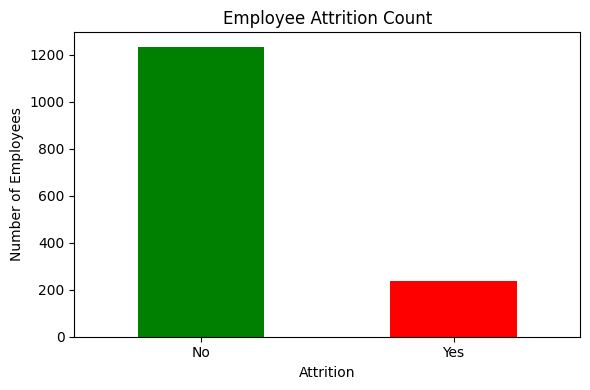

In [4]:
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print("Attrition Rate:")
print(attrition_rate.round(2))

plt.figure(figsize=(6,4))
df['Attrition'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Employee Attrition Count')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('1_attrition_count.png')
plt.show()

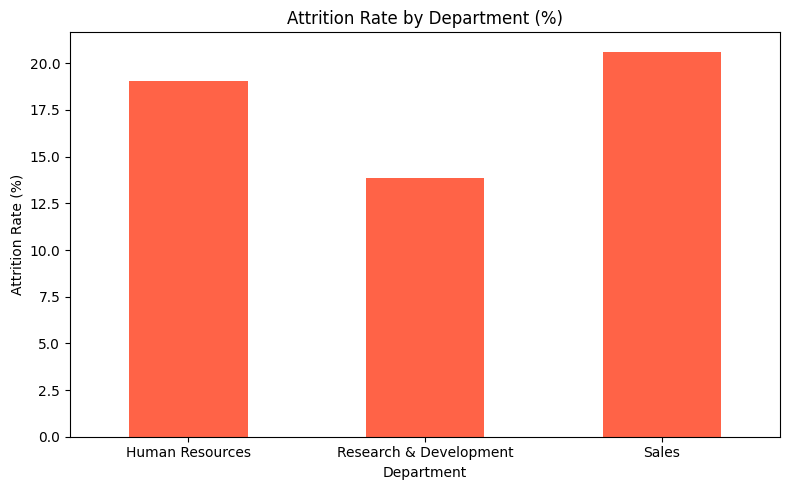

In [5]:
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(8,5))
dept_attrition['Yes'].plot(kind='bar', color='tomato')
plt.title('Attrition Rate by Department (%)')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('2_attrition_by_department.png')
plt.show()

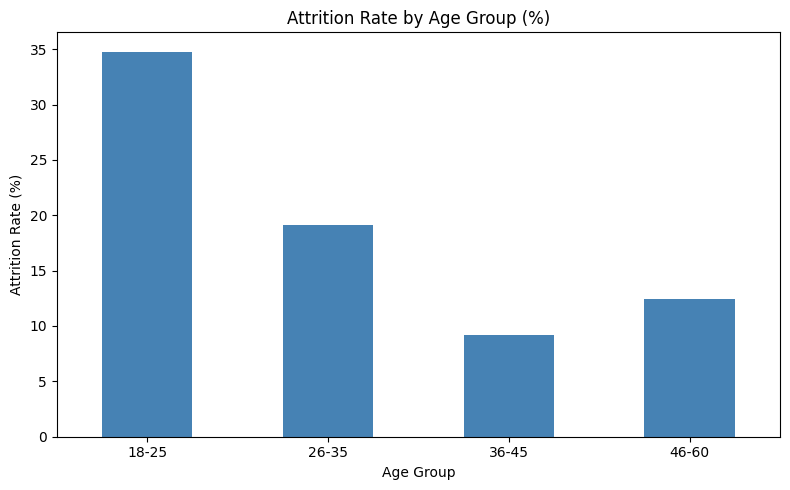

In [6]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,60],
                         labels=['18-25','26-35','36-45','46-60'])

age_attrition = df.groupby('AgeGroup')['Attrition'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(8,5))
age_attrition['Yes'].plot(kind='bar', color='steelblue')
plt.title('Attrition Rate by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('3_attrition_by_age.png')
plt.show()

C:\Users\Suriya Krishna\AppData\Local\Temp\ipykernel_1388\1754822806.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,


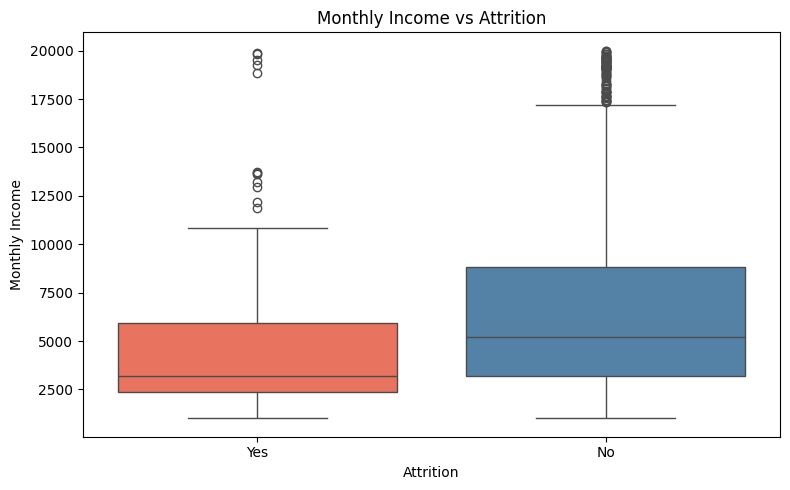

Average Salary:
Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64


In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            palette={'Yes':'tomato','No':'steelblue'})
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('4_salary_vs_attrition.png')
plt.show()

print("Average Salary:")
print(df.groupby('Attrition')['MonthlyIncome'].mean().round(2))

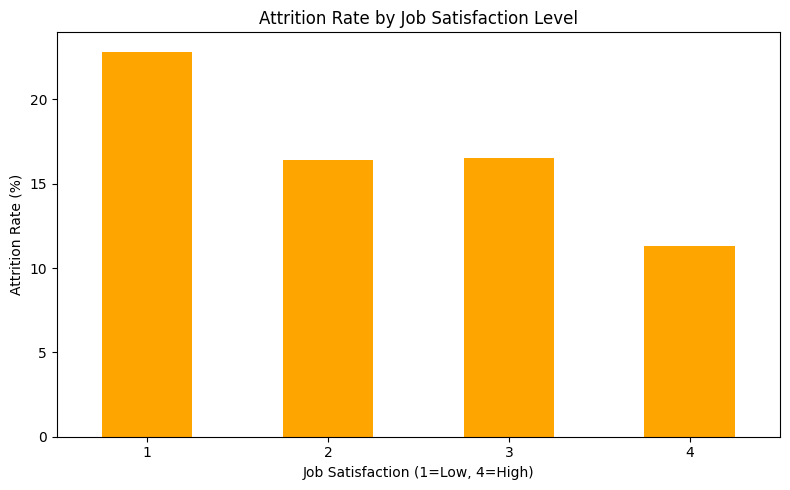

In [8]:
satisfaction = df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(8,5))
satisfaction['Yes'].plot(kind='bar', color='orange')
plt.title('Attrition Rate by Job Satisfaction Level')
plt.xlabel('Job Satisfaction (1=Low, 4=High)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('5_satisfaction_vs_attrition.png')
plt.show()

In [9]:
print("=" * 50)
print("KEY FINDINGS — HR ATTRITION ANALYSIS")
print("=" * 50)

total = len(df)
attrition_yes = len(df[df['Attrition'] == 'Yes'])
rate = round(attrition_yes / total * 100, 2)

print(f"\n Total Employees : {total}")
print(f" Employees Left  : {attrition_yes}")
print(f" Attrition Rate  : {rate}%")

print(f"\n Avg Salary (Stayed) : {df[df['Attrition']=='No']['MonthlyIncome'].mean():.2f}")
print(f" Avg Salary (Left)   : {df[df['Attrition']=='Yes']['MonthlyIncome'].mean():.2f}")

top_dept = dept_attrition['Yes'].idxmax()
print(f"\n Highest Attrition Dept : {top_dept}")

top_age = age_attrition['Yes'].idxmax()
print(f" Highest Attrition Age  : {top_age}")

print("\n" + "=" * 50)
print("Analysis Complete!")

KEY FINDINGS — HR ATTRITION ANALYSIS

 Total Employees : 1470
 Employees Left  : 237
 Attrition Rate  : 16.12%

 Avg Salary (Stayed) : 6832.74
 Avg Salary (Left)   : 4787.09

 Highest Attrition Dept : Sales
 Highest Attrition Age  : 18-25

Analysis Complete!
